1. Fetching dataset from the google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Extracting the dataset

In [ ]:
import zipfile, os

zip_path = "/content/drive/MyDrive/anti_spoofing_dataset.zip"
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/dataset


3. Fetchinh the files from the Folder

In [ ]:
for root, dirs, files in os.walk(extract_path):
    print(root, "->", len(files), "files")

/content/dataset -> 0 files
/content/dataset/raw -> 4 files
/content/dataset/raw/ImposterRaw -> 0 files
/content/dataset/raw/ImposterRaw/0012 -> 385 files
/content/dataset/raw/ImposterRaw/0010 -> 243 files
/content/dataset/raw/ImposterRaw/0005 -> 596 files
/content/dataset/raw/ImposterRaw/0001 -> 615 files
/content/dataset/raw/ImposterRaw/0007 -> 606 files
/content/dataset/raw/ImposterRaw/0008 -> 600 files
/content/dataset/raw/ImposterRaw/0009 -> 603 files
/content/dataset/raw/ImposterRaw/0002 -> 610 files
/content/dataset/raw/ImposterRaw/0003 -> 604 files
/content/dataset/raw/ImposterRaw/0016 -> 469 files
/content/dataset/raw/ImposterRaw/0011 -> 304 files
/content/dataset/raw/ImposterRaw/0006 -> 459 files
/content/dataset/raw/ImposterRaw/0015 -> 380 files
/content/dataset/raw/ImposterRaw/0004 -> 609 files
/content/dataset/raw/ImposterRaw/0014 -> 440 files
/content/dataset/raw/ClientRaw -> 0 files
/content/dataset/raw/ClientRaw/0012 -> 436 files
/content/dataset/raw/ClientRaw/0010 -> 7

4. Spliting the files into Train/Test/Val

In [ ]:
import os, shutil
from sklearn.model_selection import train_test_split

raw_client = "/content/dataset/raw/ClientRaw"
raw_imposter = "/content/dataset/raw/ImposterRaw"

# Target dirs
train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"

for path in [train_dir, test_dir]:
    os.makedirs(os.path.join(path, "REAL"), exist_ok=True)
    os.makedirs(os.path.join(path, "SPOOF"), exist_ok=True)

def collect_files(src_dir):
    all_files = []
    for root, dirs, files in os.walk(src_dir):
        for f in files:
            if f.lower().endswith(('.jpg','.png','.jpeg')):
                all_files.append(os.path.join(root, f))
    return all_files

real_images = collect_files(raw_client)
fake_images = collect_files(raw_imposter)

print("REAL images:", len(real_images))
print("FAKE images:", len(fake_images))

# Split into train/test
train_real, test_real = train_test_split(real_images, test_size=0.2, random_state=42)
train_fake, test_fake = train_test_split(fake_images, test_size=0.2, random_state=42)

def copy_files(file_list, target_dir):
    for f in file_list:
        shutil.copy(f, target_dir)

# Copy REAL
copy_files(train_real, os.path.join(train_dir,"REAL"))
copy_files(test_real, os.path.join(test_dir,"REAL"))

# Copy SPOOF
copy_files(train_fake, os.path.join(train_dir,"SPOOF"))
copy_files(test_fake, os.path.join(test_dir,"SPOOF"))

print("Dataset reorganized successfully!")

REAL images: 5105
FAKE images: 7509
Dataset reorganized successfully!


5. Importing the Required Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

6. Data Augmentation

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary",
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary",
    subset='validation'
)

Found 8074 images belonging to 2 classes.
Found 2017 images belonging to 2 classes.


7. Creates the class weight

In [ ]:
labels = train_gen.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.23531211750306), 1: np.float64(0.8399916770703287)}


8. Building the model ResNet50 + VGG16 with skip connection

In [ ]:
# ResNet50 base
resnet_base = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
resnet_base.trainable = False

# VGG16 base
vgg_base = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
vgg_base.trainable = False

# Inputs
inputs = Input(shape=(224,224,3))

# Extract features
resnet_features = resnet_base(inputs)
resnet_features = GlobalAveragePooling2D()(resnet_features)

vgg_features = vgg_base(inputs)
vgg_features = GlobalAveragePooling2D()(vgg_features)

# Skip connection = Concatenate
merged = Concatenate()([resnet_features, vgg_features])

# Dense layers
x = Dense(256, activation="relu")(merged)
x = Dropout(0.5)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

# Output layer
outputs = Dense(1, activation="sigmoid")(x)

# Final Model
model = Model(inputs=inputs, outputs=outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


9. Model Compilation

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input_layer_2[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    655,616 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,991,041 (148.74 MB)

 Trainable params: 688,641 (2.63 MB)

 Non-trainable params: 38,302,400 (146.11 MB)

10. Model Training

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 212s 729ms/step - accuracy: 0.6013 - loss: 0.6697 - val_accuracy: 0.8661 - val_loss: 0.3410
Epoch 2/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 162s 641ms/step - accuracy: 0.9274 - loss: 0.2652 - val_accuracy: 0.9192 - val_loss: 0.2236
Epoch 3/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 202s 641ms/step - accuracy: 0.9650 - loss: 0.1204 - val_accuracy: 0.9147 - val_loss: 0.1853
Epoch 4/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 169s 668ms/step - accuracy: 0.9820 - loss: 0.0691 - val_accuracy: 0.9182 - val_loss: 0.2061
Epoch 5/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 162s 638ms/step - accuracy: 0.9834 - loss: 0.0532 - val_accuracy: 0.9251 - val_loss: 0.1688
Epoch 6/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 161s 635ms/step - accuracy: 0.9873 - loss: 0.0450 - val_accuracy: 0.9321 - val_loss: 0.1716
Epoch 7/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 160s 634ms/step - accuracy: 0.9907 - loss: 0.0334 - val_accuracy: 0.9395 - val_loss: 0.1520
Epoch 8/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 161s 636ms/step - accuracy: 0.9910 -

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255) # Only rescaling for test data

test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False # Do not shuffle test data
)

Found 2523 images belonging to 2 classes.


11. Model Accuracy

In [ ]:
loss, acc = model.evaluate(test_gen)
print(f"Test Accuracy: {acc*100:.2f}%")

79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 480ms/step - accuracy: 0.9935 - loss: 0.0212
Test Accuracy: 98.65%


12. Graph Plotting of Model Accuracy and Modle Loss

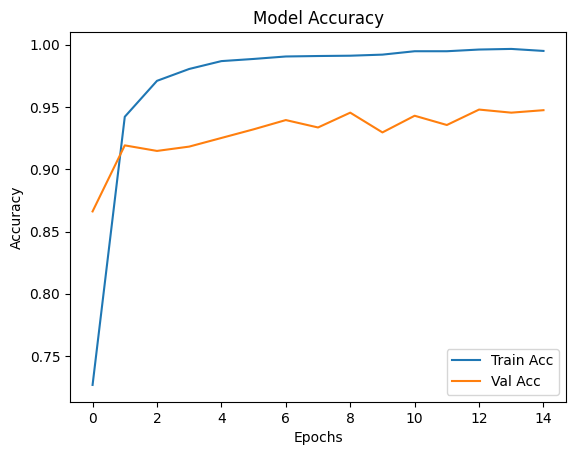

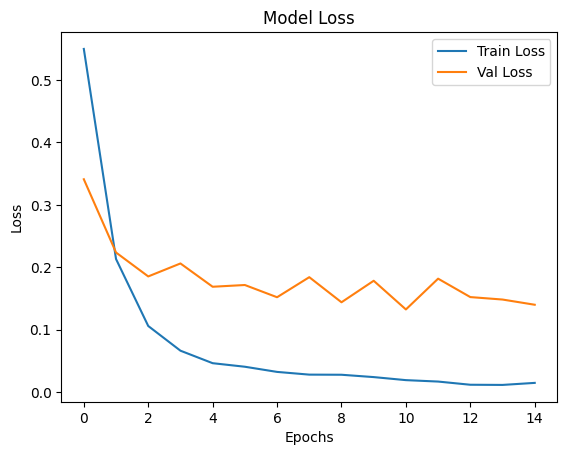

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

13. Unfreezing the last few layers of ResNet50 and VGG16

In [ ]:
for layer in resnet_base.layers[-30:]:
    layer.trainable = True
for layer in vgg_base.layers[-30:]:
    layer.trainable = True

model.compile(optimizer=Adam(1e-5), loss="binary_crossentropy", metrics=["accuracy"])

14. Computer Vision Implementation

In [ ]:
import cv2
from tensorflow.keras.preprocessing.image import img_to_array

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    face = cv2.resize(frame, (224,224))
    face = img_to_array(face) / 255.0
    face = np.expand_dims(face, axis=0)

    pred = model.predict(face)[0][0]
    label = "REAL" if pred < 0.5 else "SPOOF"

    cv2.putText(frame, label, (50,50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
    cv2.imshow("Anti-Spoofing", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

15. Confusion Matrix

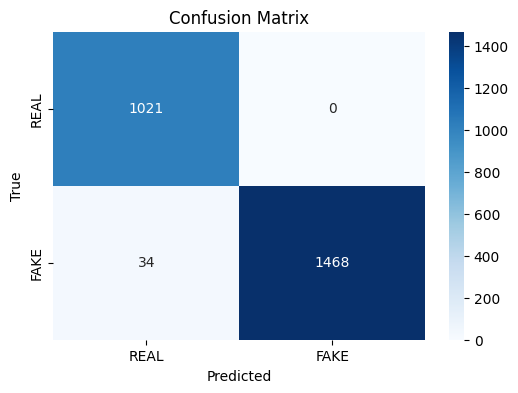

              precision    recall  f1-score   support

        REAL       0.97      1.00      0.98      1021
        FAKE       1.00      0.98      0.99      1502

    accuracy                           0.99      2523
   macro avg       0.98      0.99      0.99      2523
weighted avg       0.99      0.99      0.99      2523



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["REAL", "FAKE"], yticklabels=["REAL", "FAKE"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_true, y_pred, target_names=["REAL", "FAKE"]))

16. Model Saving

In [ ]:
model.save("antispoofing_model.h5")

17. Drive Mounting

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/antispoof_model.h5 /content/drive/MyDrive/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot stat '/content/antispoof_model.h5': No such file or directory


18.Model Download

In [ ]:
from google.colab import files
files.download("/content/anti_spoofing_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>